<a href="https://colab.research.google.com/github/2xsec/2xsec.github.io/blob/master/01_titanic_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Titanic 실습: 전처리 + PyTorch MLP**

이 노트북은 전처리부터 PyTorch 학습까지 한 번에 이어지는 실습 파일입니다.
먼저 데이터 구조를 확인한 뒤, 전처리와 모델 학습을 순서대로 진행합니다.

1. 데이터 로드
2. 수치형 표준화(정규화) 구현
3. PyTorch 데이터셋 구축 (+ train/valid 분리)
4. 모델 정의 및 학습
5. 자율실습

# 0. Colab 환경설정
- colab에서 GPU를 사용할 수 있도록 세팅
    - 런타임 > 런타임 유형 변경 > Python 3 와 T4 GPU 선택
- colab에서 Google Drive에 접근할 수 있도록 설정

In [11]:
from google.colab import drive
drive.mount('/content/drive')

print("[현재 파일 위치]")
!pwd
print("[현재 디렉토리의 파일 확인]")
!ls

Mounted at /content/drive
[현재 파일 위치]
/content
[현재 디렉토리의 파일 확인]
drive  sample_data


이제 `day1` 폴더로 이동합니다.  
이 폴더에는 `titanic_preprocessed.csv`와 실습 파일이 들어 있으므로, 이후 셀들이 같은 경로를 기준으로 동작합니다.

In [12]:
%cd /content/drive/MyDrive/day1

/content/drive/.shortcut-targets-by-id/14tWNTY4XR3u9s_HAqwbH1vpIHSLUipBb/day1


## 0-1. Setup
전처리와 학습에 필요한 `numpy`, `pandas`, `matplotlib`를 먼저 불러옵니다.  
또한 이후 모델 평가에 사용할 `accuracy_score`도 함께 준비합니다.  
디바이스와 시드도 고정해둡니다.

In [13]:
import warnings

import torch
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import accuracy_score
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 재현 가능한(reproducible) 실습을 위해 시드를 고정한다.
SEED = 42
torch.manual_seed(SEED)                 # PyTorch CPU 연산 시드 고정
if torch.cuda.is_available():           # GPU를 사용할 경우 GPU용 시드도 함께 고정
    torch.cuda.manual_seed_all(SEED)

# 1. 데이터 전처리
이 파트에서는 원본 Titanic 데이터를 확인하고, 학습에 사용할 수 있도록 전처리하는 과정을 진행합니다.  
결측치 처리, 범주형 인코딩 등 대부분의 전처리는 미리 완료되어 있으며, 여기서는 수치형 표준화(정규화)를 해봅니다.

## 1-1. 데이터 로드와 컬럼 이해
실습에 사용할 Titanic 원본 CSV를 불러오고, 데이터 크기와 칼럼 구성을 확인합니다.  
아래 설명을 보면서 어떤 컬럼이 입력 변수이고 어떤 컬럼이 정답이 될 수 있는지 미리 구분해 보세요.

- `Survived`: 승객이 생존(1)했는지 사망(0)했는지 여부 (예측 목표)
- `Pclass`: 선실 등급(1:1등급, 2:2등급, 3:3등급)
- `Sex`: 승객의 성별
- `Age`: 승객의 나이
- `SibSp`: 형제자매/배우자의 수
- `Parch`: 부모/자녀의 수
- `Fare`: 티켓에 대해 지불한 금액
- `Family`: 본인을 포함한 동승 가족 인원수
- `Embarked`: 승객이 탑승한 항구(C = Cherbourg, Q = Queenstown, S = Southampton)

In [14]:
# 결측치 처리, 이상치 제거, 파생변수(Family) 생성, 범주형 인코딩, 불필요한 열 제거는
# 미리 완료되어 'titanic_preprocessed.csv'로 제공됩니다.

df = pd.read_csv('titanic_preprocessed.csv')

print(f'데이터 크기: {df.shape}')
print('\n칼럼 목록:')
print(df.columns.tolist())
print('\n상위 5개 행:')
display(df.head())

데이터 크기: (888, 11)

칼럼 목록:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

상위 5개 행:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Family,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,1,0,0
2,1,3,1,26.0,0,0,7.9250,1,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,0,1
4,0,3,0,35.0,0,0,8.0500,1,0,0,1


## 1-2. 수치형 표준화 (정규화)
결측치 처리, 이상치 제거, 파생변수 생성, 범주형 인코딩, 불필요한 열 제거는 미리 완료되어 `titanic_preprocessed.csv`로 제공됩니다.  
이 파트에서는 남은 전처리 단계인 **수치형 표준화(정규화)** 만 직접 구현하고, 독립변수(`X`)와 종속변수(`y`)로 나눕니다.

In [15]:
# 여기서는 남은 전처리 단계인 '수치형 표준화(정규화)'만 직접 구현합니다.

def standardize_numeric(df, numeric_cols):
    # ============================================================
    # [실습 1-2] 표준화 공식: (값 - 평균) / 표준편차
    # - [빈칸 1]: 빼야 할 값
    # - [빈칸 2]: 나누어야 할 값
    # ============================================================
    out = df.copy()
    for col in numeric_cols:
        mean_val = out[col].mean()  # 평균
        std_val = out[col].std()    # 표준편차
        if std_val == 0 or pd.isna(std_val):
            std_val = 1.0
        out[col] = (out[col] - mean_val) / std_val
    return out


numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'Family']
df = standardize_numeric(df, numeric_cols)

X = df.drop(columns=['Survived'])
y = df['Survived']

print(f'전처리 후 데이터 크기: {X.shape}')
print(f'입력 특성 목록: {X.columns.tolist()}')

전처리 후 데이터 크기: (888, 10)
입력 특성 목록: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


# 메모
# 전처리 후 데이터 크기: (888, 10) ==> 888개 데이터마다 10개의 특징이 있다는 의미

# 2. MLP 모델 학습
이제 전처리된 데이터를 분할하고 PyTorch 텐서로 바꾼 뒤, MLP 모델을 정의하고 학습을 진행합니다.  
이 파트에서는 데이터셋 분할을 비롯해 `TensorDataset`, `DataLoader`, `nn.Linear`, `BCEWithLogitsLoss` 등의 기능을 활용합니다.

## 2-1. 데이터 분할 및 PyTorch 데이터 준비
학습용 데이터와 평가용 데이터로 나누는 데이터 분할 함수를 적용합니다.  
그 후 전처리된 데이터를 `numpy` 배열과 `torch.Tensor`로 바꾸고, `TensorDataset`과 `DataLoader`를 사용해 미니배치 학습이 가능하도록 묶습니다.

In [18]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

def split_train_test(X, y, test_ratio=0.2, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)
    test_size = int(len(X) * test_ratio)
    test_idx = indices[:test_size]
    train_idx = indices[test_size:]
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)
    return X_train, X_test, y_train, y_test

# 데이터 분할 비율 (추천 시도값: 0.1, 0.2(기본), 0.3), 보통 10~ 20% 정도를 test data로 활용
test_ratio = 0.2
# 한 번에 학습할 샘플 수 (추천 시도값: 16, 32(기본), 64), 그면 클수록 속도가 빨라지고 정확도 올라가지만, 메모리 사용량이 크게 증가
batch_size = 32

X_train, X_test, y_train, y_test = split_train_test(X, y, test_ratio=test_ratio, shuffle=True)    # 학습 데이터(train)와 평가 데이터(test)를 별도로 준비

X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1)
y_test_np = y_test.values.astype(np.float32).reshape(-1, 1)

X_train_tensor = torch.tensor(X_train_np)      # 전처리된 데이터를 텐서로 변환, Dataset으로 제공
y_train_tensor = torch.tensor(y_train_np)      #
X_test_tensor = torch.tensor(X_test_np)        #
y_test_tensor = torch.tensor(y_test_np)        #

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_dim = X_train_tensor.shape[1]
print('입력 차원:', input_dim)
print('train sample 수:', len(train_dataset), '| test sample 수:', len(test_dataset))

입력 차원: 10
train sample 수: 711 | test sample 수: 177


shape()

## 2-2. 모델 구조와 학습/평가 루프
입력 특성을 점차 압축해 생존 여부를 구분하기 쉽게 만드는 작은 MLP 입니다.
- `BasicMLP` : (`input_dim → hidden → output`)을 가지는 단순한 모델

In [19]:
class BasicMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # ============================================================
        # [실습 2-2] BasicMLP를 채워 보세요.
        # - 은닉층은 hidden_dim 차원으로 고정합니다.
        # - 우리는 이진 분류(생존/사망) 이므로 출력값이 몇 개 필요할지 생각해 보세요.
        # - [빈칸] ? 자리에 알맞은 값을 채우세요.
        # ============================================================
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),    # 입력 차원 -> 은닉 차원
            nn.ReLU(),                           # 은닉층의 비선형 활성화 함수
            nn.Linear(hidden_dim, 1),            # 은닉 차원 -> 출력 차원 (생존 확률), 현재는 생존여부만 보므로, 이진 출력임
        )

    def forward(self, x):
        return self.net(x)

- `BCEWithLogitsLoss`: 마지막 출력에 sigmoid를 따로 붙이지 않고도 안정적으로 이진분류 손실을 계산합니다.

In [25]:
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    pred_list, target_list = [], []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            pred_list.append(preds.cpu().numpy())
            target_list.append(yb.cpu().numpy())

    y_pred = np.vstack(pred_list).ravel()
    y_true = np.vstack(target_list).ravel()
    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc

def train_model(model, train_loader, test_loader, epochs=100, lr=0.01):

    # criterion은 손실을 계산하는 손실 함수(loss function)입니다.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': [],
    }

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        train_pred_list, train_target_list = [], []

        for xb, yb in train_loader:
            optimizer.zero_grad()
            xb, yb = xb.to(device), yb.to(device)

            # ============================================================
            # [실습 2-2] 학습 한 스텝의 핵심 2줄을 직접 채워 보세요.
            # - 빈칸 1: 모델에 입력(xb) 을 넣어 logits 을 얻습니다.
            # - 빈칸 2: 손실 함수에 (logits, 정답yb) 을 넣어 loss 를 계산합니다.
            # ============================================================
            logits = model(xb)          ### [실습] model()은 BasicMLP 클래스의 forward() 메서드를 호출합니다.
            loss = criterion(logits, yb)    ### [실습] loss 함수에 모델의 출력과 정답을 넣어 손실을 계산합니다.

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * xb.size(0)
            probs = torch.sigmoid(logits)
            # ============================================================
            # [실습 2-2] 시그모이드 출력 확률(probs)를 기준으로 예측값(preds)을 만들어 보세요.
            # - 확률이 0.5 이상이면 1(생존), 그렇지 않으면 0(사망)으로 예측합니다.
            # - [빈칸] ? 자리에 예측값을 예측 기준치(얼마 이상인지?)를 채우세요.
            # ============================================================
            preds = (probs >= 0.5).float()
            train_pred_list.append(preds.detach().cpu().numpy())
            train_target_list.append(yb.detach().cpu().numpy())

        train_loss = train_loss_sum / len(train_loader.dataset)
        train_pred = np.vstack(train_pred_list).ravel()
        train_true = np.vstack(train_target_list).ravel()
        train_acc = accuracy_score(train_true, train_pred)

        test_loss, test_acc = evaluate_model(model, test_loader, criterion)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if epoch % 10 == 0:
            print(
                f'Epoch {epoch:03d} | '
                f'Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | '
                f'Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}'
            )

    final_test_loss, final_test_acc = evaluate_model(model, test_loader, criterion)
    return history, final_test_loss, final_test_acc

## 2-3. 기본 MLP 학습
이제 준비한 함수를 실제로 실행합니다.
먼저 `BasicMLP`를 학습시켜 기준 성능을 확인합니다.

이 단계에서 학생들이 꼭 챙겨야 할 포인트는 다음입니다.
- `epochs=100`: 같은 데이터를 여러 번 반복해서 학습합니다.
- `lr=0.01`: Adam 옵티마이저의 학습률입니다. 너무 크면 불안정하고, 너무 작으면 학습이 느립니다.
- `batch_size=32`: 한 번에 32개 샘플로 기울기를 계산합니다.
- `shuffle=True`: 매 epoch마다 데이터 순서를 섞어 편향된 학습을 줄입니다.

In [26]:
# 학습 epoch 수 (추천 시도값: 50, 100(기본), 200)
epochs = 100

# 학습률 (추천 시도값: 0.001, 0.005, 0.01(기본), 0.05)
lr = 0.01

# 은닉층 차원
hidden_dim = 4

# 모델 생성
model = BasicMLP(input_dim=input_dim, hidden_dim=hidden_dim).to(device)

# 모델 학습
history, test_loss, test_acc = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=lr,
)

print(f'\nBasic MLP 최종 테스트 성능 - Loss: {test_loss:.4f} | Acc: {test_acc:.4f}')

Epoch 000 | Train Loss: 0.6791 | Test Loss: 0.5498 | Train Acc: 0.5527 | Test Acc: 0.7910
Epoch 010 | Train Loss: 0.4566 | Test Loss: 0.3657 | Train Acc: 0.7862 | Test Acc: 0.8475
Epoch 020 | Train Loss: 0.4494 | Test Loss: 0.3552 | Train Acc: 0.7904 | Test Acc: 0.8475
Epoch 030 | Train Loss: 0.4462 | Test Loss: 0.3743 | Train Acc: 0.7989 | Test Acc: 0.8362
Epoch 040 | Train Loss: 0.4351 | Test Loss: 0.3596 | Train Acc: 0.8101 | Test Acc: 0.8701
Epoch 050 | Train Loss: 0.4306 | Test Loss: 0.3573 | Train Acc: 0.8129 | Test Acc: 0.8531
Epoch 060 | Train Loss: 0.4260 | Test Loss: 0.3536 | Train Acc: 0.8186 | Test Acc: 0.8701
Epoch 070 | Train Loss: 0.4219 | Test Loss: 0.3377 | Train Acc: 0.8242 | Test Acc: 0.8531
Epoch 080 | Train Loss: 0.4303 | Test Loss: 0.3509 | Train Acc: 0.8186 | Test Acc: 0.8531
Epoch 090 | Train Loss: 0.4209 | Test Loss: 0.3404 | Train Acc: 0.8214 | Test Acc: 0.8757

Basic MLP 최종 테스트 성능 - Loss: 0.3333 | Acc: 0.8701


# 메모
# Basic MLP 최종 테스트 성능 - Loss: 0.3333 | Acc: 0.8701

# 3. 더 깊은 MLP
앞의 `BasicMLP`는 은닉층 1개짜리 아주 작은 기준 모델이었습니다.
이제 은닉층을 더 쌓은 `DeepMLP`를 직접 만들어, 모델을 키우면 성능이 어떻게 달라지는지 확인합니다.  
작은 데이터에서는 모델을 키우는 것이 항상 이득은 아니므로, 성능과 과적합(train↔test 격차)을 함께 관찰하는 것이 핵심입니다.

## 3-1. 더 깊은 MLP 쌓아보기
추천 구조는 `input_dim → 128 → 64 → 32 → 1` 입니다.
- 은닉층 3개(128, 64, 32)를 쌓고, 각 `Linear` 뒤에 `ReLU`를 둡니다.
- 핵심 규칙: 이전 `Linear`의 출력 크기가 다음 `Linear`의 입력 크기가 되어야 합니다.
- 마지막 출력은 이진분류이므로 1개입니다.

학습 후 `BasicMLP`와 성능을 비교해 보세요.

In [27]:
# ============================================================
# [실습 3-1] DeepMLP 를 직접 완성하세요.
# - input_dim → hidden1 → hidden2 → hidden3 → 1
# - 은닉층 3개(hidden1, hidden2, hidden3) 각각 뒤에 ReLU 를 두고, 마지막 출력은 1 입니다.
# - 규칙: 이전 Linear 의 출력 크기 = 다음 Linear 의 입력 크기
# - 첫 은닉층(input_dim → hidden1)은 예시로 채워 두었습니다. 나머지 ? 를 채우세요.
# ============================================================
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, hidden3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),  # 입력 차원 → hidden1
            nn.ReLU(),
            nn.Linear(128, 64),  # hidden1 → hidden2
            nn.ReLU(),
            nn.Linear(64, 32),  # hidden2 → hidden3
            nn.ReLU(),
            nn.Linear(32, 1),  # hidden3 → 출력
        )

    def forward(self, x):
        return self.net(x)


In [28]:
hidden1, hidden2, hidden3 = 128, 64, 32

deep_model = DeepMLP(input_dim, hidden1, hidden2, hidden3).to(device)
deep_history, deep_test_loss, deep_test_acc = train_model(
    deep_model, train_loader, test_loader, epochs=100, lr=0.01,
)

print(f'\nDeep MLP 최종 테스트 성능 - Loss: {deep_test_loss:.4f} | Acc: {deep_test_acc:.4f}')

Epoch 000 | Train Loss: 0.5819 | Test Loss: 0.3712 | Train Acc: 0.6962 | Test Acc: 0.8644
Epoch 010 | Train Loss: 0.4164 | Test Loss: 0.3618 | Train Acc: 0.8256 | Test Acc: 0.8814
Epoch 020 | Train Loss: 0.3821 | Test Loss: 0.3395 | Train Acc: 0.8312 | Test Acc: 0.8814
Epoch 030 | Train Loss: 0.3726 | Test Loss: 0.3393 | Train Acc: 0.8481 | Test Acc: 0.8588
Epoch 040 | Train Loss: 0.3759 | Test Loss: 0.3636 | Train Acc: 0.8551 | Test Acc: 0.8531
Epoch 050 | Train Loss: 0.3409 | Test Loss: 0.3954 | Train Acc: 0.8579 | Test Acc: 0.8418
Epoch 060 | Train Loss: 0.3292 | Test Loss: 0.3798 | Train Acc: 0.8608 | Test Acc: 0.8531
Epoch 070 | Train Loss: 0.3075 | Test Loss: 0.4472 | Train Acc: 0.8664 | Test Acc: 0.8701
Epoch 080 | Train Loss: 0.3241 | Test Loss: 0.4745 | Train Acc: 0.8622 | Test Acc: 0.8588
Epoch 090 | Train Loss: 0.3104 | Test Loss: 0.5166 | Train Acc: 0.8748 | Test Acc: 0.8305

Deep MLP 최종 테스트 성능 - Loss: 0.5543 | Acc: 0.8701


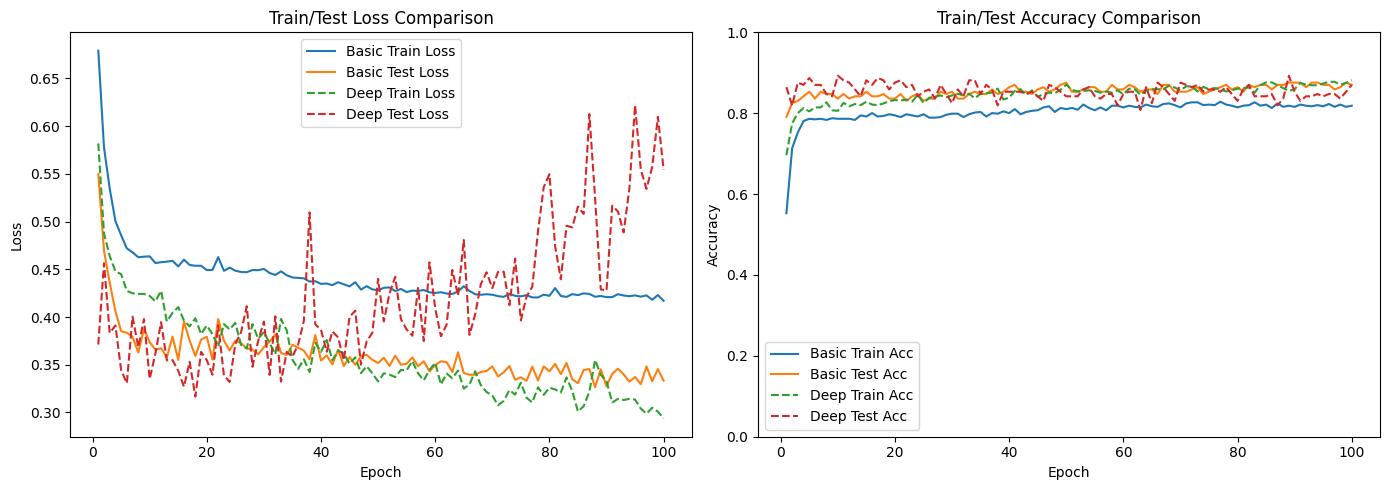

In [29]:
# Basic vs Deep 비교 그래프
epochs_basic = np.arange(1, len(history['train_loss']) + 1)
epochs_deep = np.arange(1, len(deep_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_basic, history['train_loss'], label='Basic Train Loss')
axes[0].plot(epochs_basic, history['test_loss'], label='Basic Test Loss')
axes[0].plot(epochs_deep, deep_history['train_loss'], linestyle='--', label='Deep Train Loss')
axes[0].plot(epochs_deep, deep_history['test_loss'], linestyle='--', label='Deep Test Loss')
axes[0].set_title('Train/Test Loss Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs_basic, history['train_acc'], label='Basic Train Acc')
axes[1].plot(epochs_basic, history['test_acc'], label='Basic Test Acc')
axes[1].plot(epochs_deep, deep_history['train_acc'], linestyle='--', label='Deep Train Acc')
axes[1].plot(epochs_deep, deep_history['test_acc'], linestyle='--', label='Deep Test Acc')
axes[1].set_title('Train/Test Accuracy Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_ylim(0, 1); axes[1].legend()

plt.tight_layout()
plt.show()